In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score, f1_score
from dataloaders.CIFAR10DataLoader import CIFAR10DataLoader
from helper.arguments import get_parameter

directory = 'results/test_glare_07052025_2326'
iteration = 0
scores_df = pd.read_pickle(f'{directory}/iteration{iteration}/scores.pkl')

In [5]:
# To get the mislabeled/ clean label

with open(f'{directory}/spec.json') as f:
    spec = json.load(f)

data_module = CIFAR10DataLoader(
        spec=spec,
        noise_level=get_parameter(spec, 'noise_level', 'rand1', str),
        train_transforms=None,
        val_transforms=None,
        num_workers=12
    )

data_module.setup()

diff_indices = [i for i, (n, t) in enumerate(zip(data_module.noisy_targets, data_module.targets)) if n != t]

scores_df["mislabeled"] = scores_df["id"].apply(lambda x: 1 if x in diff_indices else 0)


100%|██████████| 170M/170M [00:15<00:00, 10.9MB/s] 


Extracting datasets/CIFAR10/cifar-10-python.tar.gz to datasets/CIFAR10


/home/student/luca_ma/glare_clean/datasets/CIFAR10/CIFAR10_dataset.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  label_file = torch.load(f'{self.root}/CIFAR-10_human.

/tmp/ipykernel_18804/1261551786.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=True, loc="lower right")


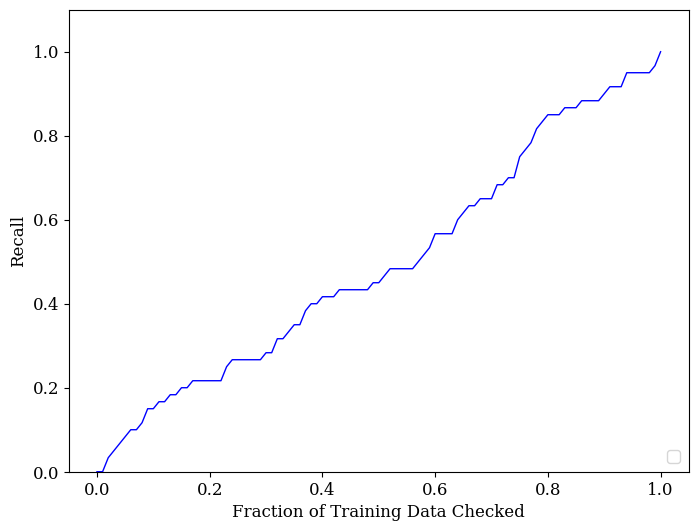

In [9]:
metric = "Recall"

metrics = []

for i in range(101):
    fraction = i / 100

    threshold = scores_df['glarex score'].quantile(fraction)
    
    mislabeles_count = scores_df[scores_df['glarex score'] <= threshold]
    non_mislabeles_count = scores_df[scores_df['glarex score'] > threshold]
    
    y_true_count = scores_df['mislabeled']
    y_pred_count = [0 if id_ in non_mislabeles_count['id'].values else 1 for id_ in scores_df['id']] 
    
    accuracy_count = accuracy_score(y_true_count, y_pred_count)
    recall_count = recall_score(y_true_count, y_pred_count, zero_division=0)
    f1_count = f1_score(y_true_count, y_pred_count, zero_division=0)
    
    metrics.append({
        'Fraction': fraction,
        'Accuracy': accuracy_count,
        'Recall': recall_count,
        'F1': f1_count
    })

metrics_df = pd.DataFrame(metrics)

metrics_melted = metrics_df.melt(
    id_vars=["Fraction"], 
    value_vars=["Accuracy", "Recall", "F1"],
    var_name="Metric", 
    value_name="Value"
)


plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12
})

df_filtered = metrics_melted[metrics_melted["Metric"] == metric]


plt.figure(figsize=(8, 6))

plt.ylim(0.0, 1.1)

plt.plot(df_filtered["Fraction"], df_filtered["Value"], color="b", linewidth=1)

plt.xlabel("Fraction of Training Data Checked")
plt.ylabel(metric)

plt.legend(frameon=True, loc="lower right")

plt.show()